In [119]:
import sklearn
import pandas as pd
import numpy as np
import random as rd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Sequential, layers, activations
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [191]:
main_df =         pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv')
holdout_df =      pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes_december.csv')
mini_holdout_df = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/biking_holdout_test_mini.csv')

In [ ]:
# COLUMNS & DESCRIPTORS

# instant: record index 
# dteday : date 
# season : season (1:winter, 2:spring, 3:summer, 4:fall) 
# hr : hour (0 to 23) 
# holiday : weather day is holiday or not
# workingday : if day is neither weekend nor holiday is 1, otherwise is 0. 
# weathersit : 
# 1: Clear, Few clouds, Partly cloudy, Partly cloudy 
# 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist 
# 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds 
# 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
# temp_c : temperature in Celsius. 
# feels_like_c: "Feels like" temperature in Celsius. 
# hum: humidity percentage
# windspeed: Wind speed.
# casual: count of casual users
# registered: count of registered users

In [121]:
# main_df.describe
main_df.describe().transpose()[['mean', 'std']]

,mean,std
season,2.482058,1.085930
hr,11.547875,6.914199
holiday,0.028671,0.166885
workingday,0.684378,0.464777
weathersit,1.415580,0.637298
hum,0.624756,0.193227
windspeed,12.750436,8.168415
temp_c,15.723008,9.041349
feels_like_c,15.852141,11.322751
casual,36.471239,49.995203


In [7]:
main_df.head()

,dteday,season,hr,holiday,workingday,weathersit,hum,windspeed,temp_c,feels_like_c,casual,registered
0,1/1/11,1,0,0,0,1,0.81,0,3.28,3.0014,3,13
1,1/1/11,1,1,0,0,1,0.80,0,2.34,1.9982,8,32
2,1/1/11,1,2,0,0,1,0.80,0,2.34,1.9982,5,27
3,1/1/11,1,3,0,0,1,0.75,0,3.28,3.0014,3,10
4,1/1/11,1,4,0,0,1,0.75,0,3.28,3.0014,0,1


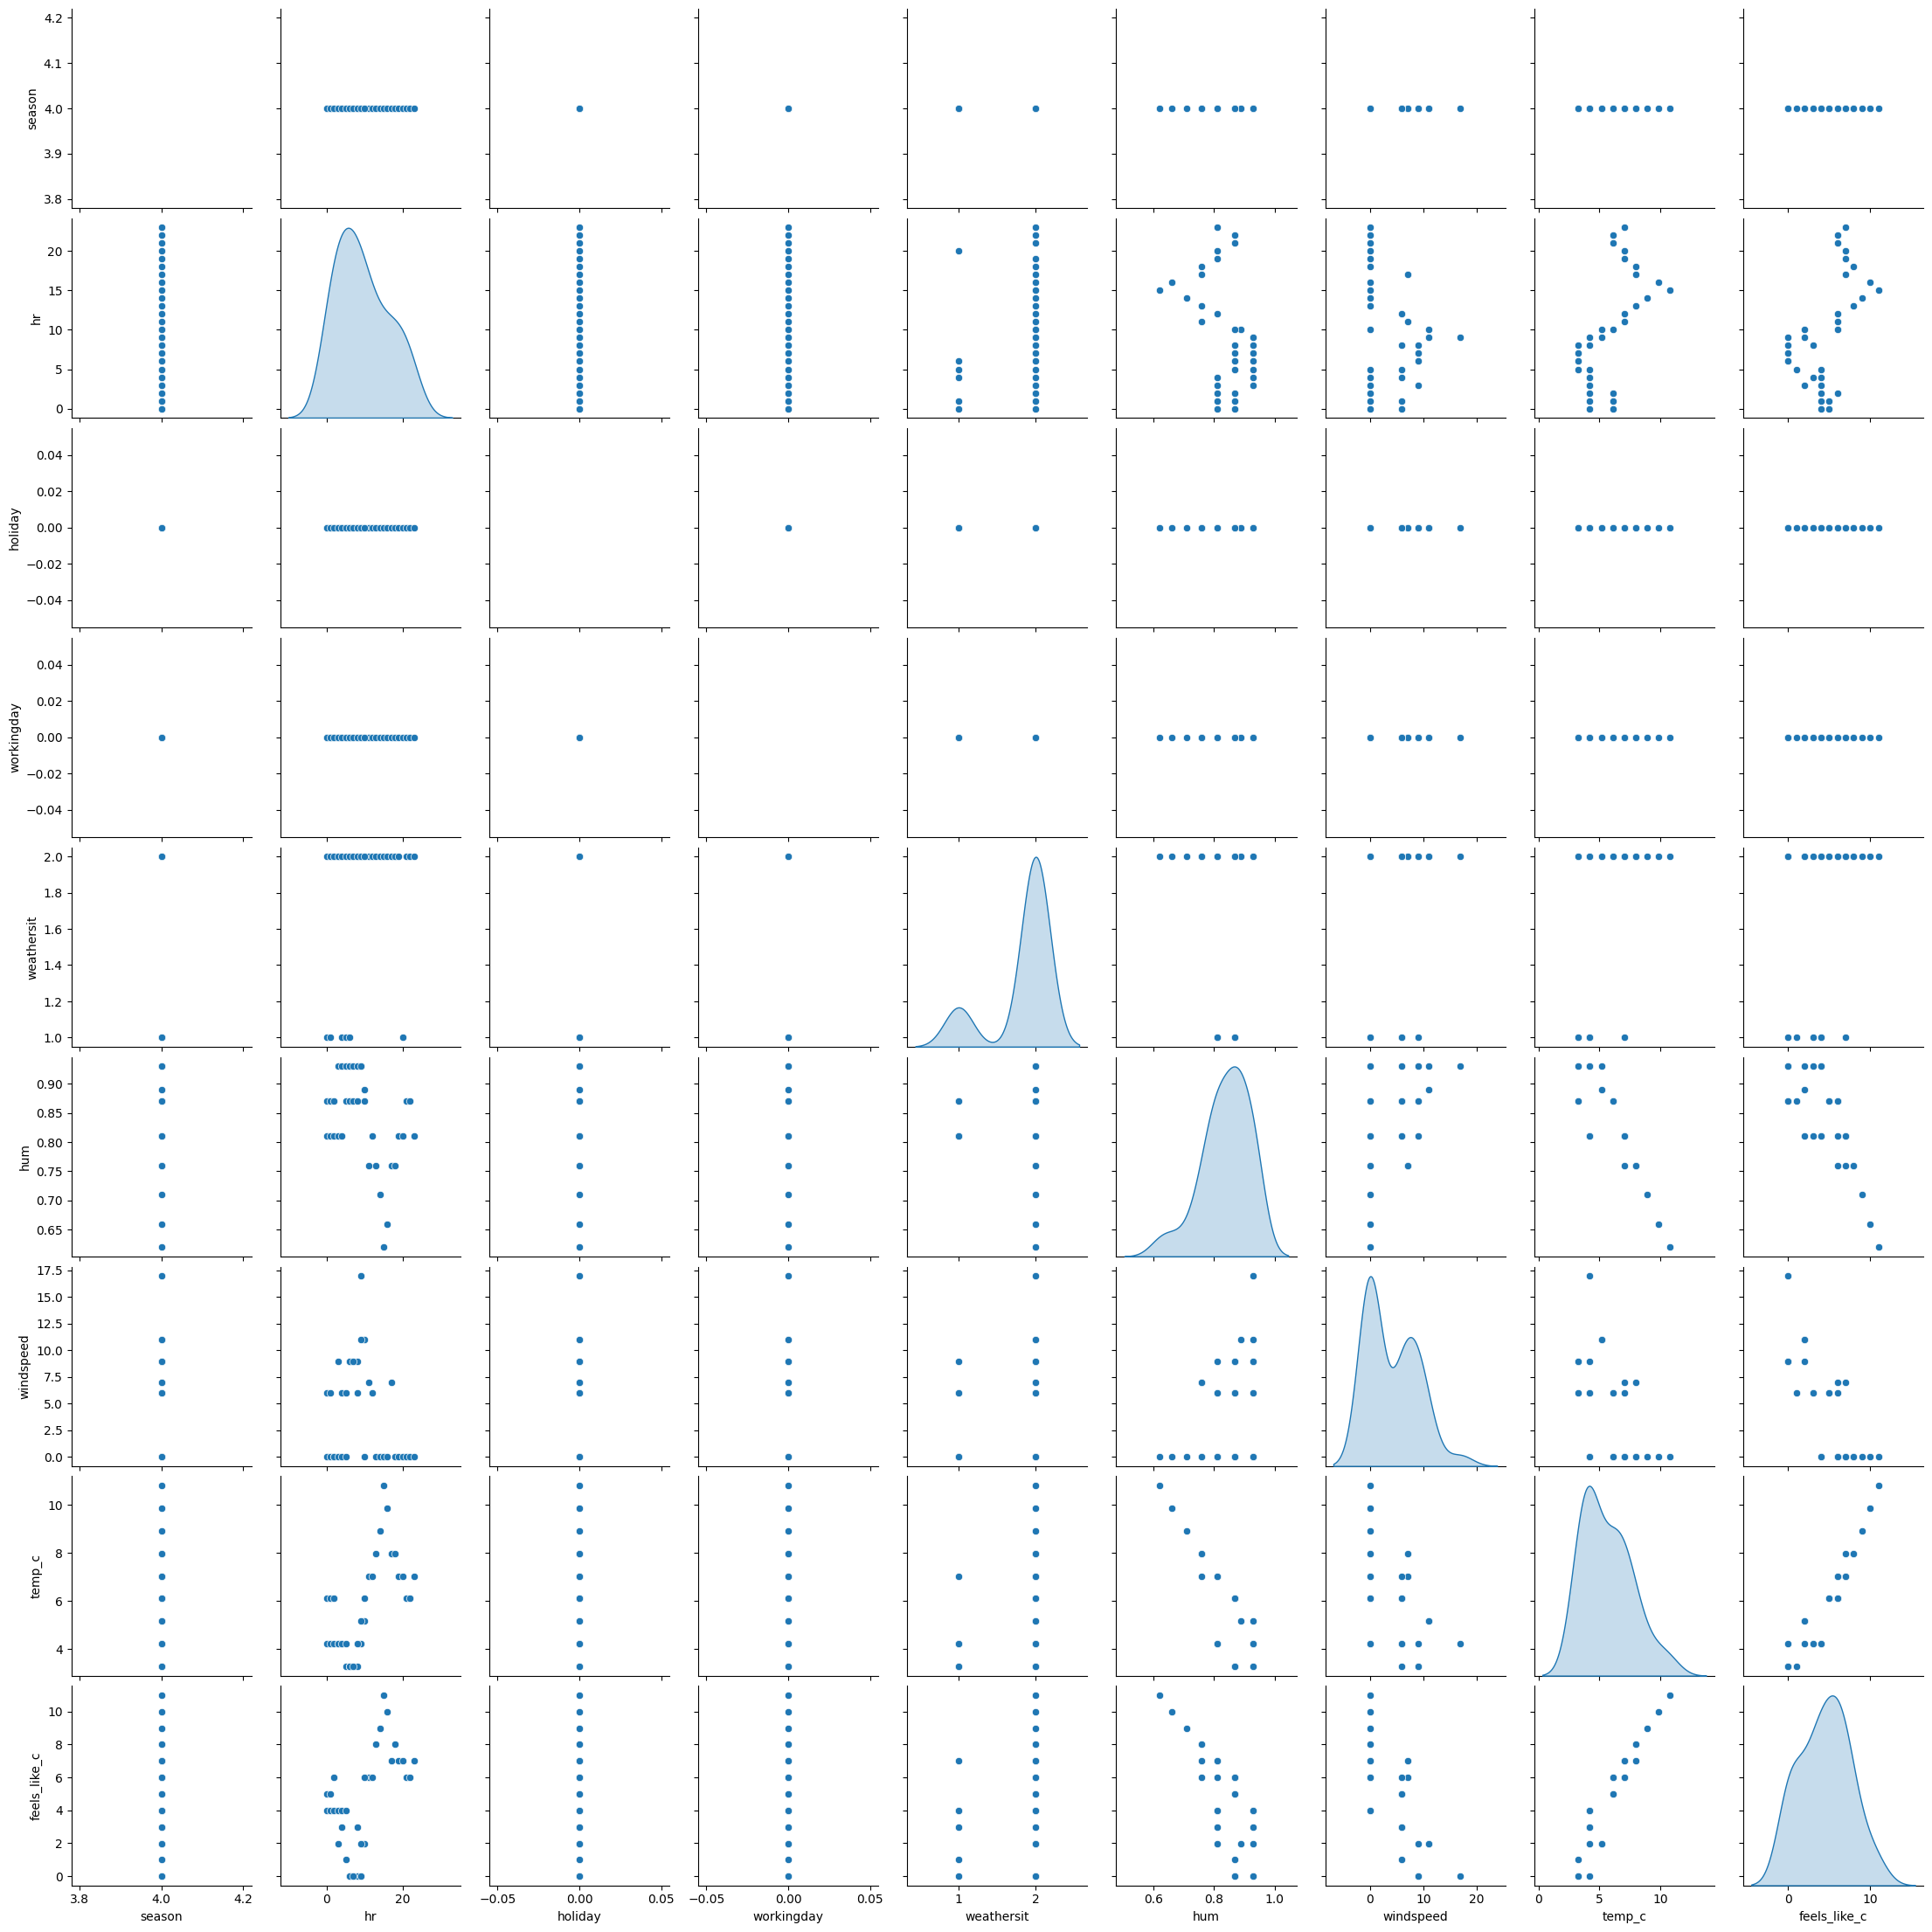

In [49]:
# visuals
# sns.scatterplot(main_df, x='hr', y='registered')
# sns.scatterplot(main_df, x='hr', y='casual')
# sns.barplot(main_df, x='weathersit', y='registered')
# sns.lineplot(main_df, x='temp_c', y='registered')
sns.pairplot(mini_holdout_df, diag_kind='kde')



In [192]:
test = [i.split('/') for i in mini_holdout_df['dteday']]
mini_holdout_df['month'] = [int(i[0]) for i in test]
mini_holdout_df['day']   = [int(i[1]) for i in test]
mini_holdout_df['year']  = [int(i[2]) for i in test]
mini_holdout_df = mini_holdout_df.drop(['dteday'], axis=1)

In [193]:
# main_encoded_df = pd.get_dummies(main_df)
test = [i.split('/') for i in main_df['dteday']]
main_df['month'] = [int(i[0]) for i in test]
main_df['day']   = [int(i[1]) for i in test]
main_df['year']  = [int(i[2]) for i in test]
main_df['rentals'] = main_df['registered'] + main_df['casual']
main_df = main_df.drop(['registered', 'casual', 'dteday'], axis=1)

In [194]:
main_encoded_df = pd.get_dummies(main_df, columns=['hr'])
mini_holdout_encoded_df = pd.get_dummies(mini_holdout_df, columns=['hr'])

In [155]:
main_encoded_df
# mini_holdout_encoded_df

,season,holiday,workingday,weathersit,hum,windspeed,temp_c,feels_like_c,month,day,...,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23
0,1,0,0,1,0.81,0,3.28,3.0014,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,1,0.80,0,2.34,1.9982,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0.80,0,2.34,1.9982,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,1,0.75,0,3.28,3.0014,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,1,0.75,0,3.28,3.0014,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16632,4,0,1,1,0.66,0,7.04,7.0010,11,30,...,0,0,0,0,0,1,0,0,0,0
16633,4,0,1,1,0.66,0,7.04,7.0010,11,30,...,0,0,0,0,0,0,1,0,0,0
16634,4,0,1,1,0.75,6,6.10,5.0012,11,30,...,0,0,0,0,0,0,0,1,0,0
16635,4,0,1,1,0.75,0,6.10,5.9978,11,30,...,0,0,0,0,0,0,0,0,1,0


In [196]:
X = main_encoded_df.drop(['rentals'], axis=1)
# y = main_encoded_df[['rentals']]
y = main_encoded_df.copy()

# X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.3, random_state=42)
X_test  = X[(X['day'] == 7) | (X['day'] == 14) | (X['day'] == 21)]
X_train = X[(X['day'] != 7) | (X['day'] != 14) | (X['day'] != 21)]
y_test  = y[(y['day'] == 7) | (y['day'] == 14) | (y['day'] == 21)]['rentals']
y_train = y[(y['day'] != 7) | (y['day'] != 21) | (y['day'] != 21)]['rentals']

In [197]:
# MODEL
Dropout, Dense = layers.Dropout, layers.Dense
mms = MinMaxScaler().fit(X_train)
X_train = mms.transform(X_train)
X_test = mms.transform(X_test)

In [198]:
model = Sequential()
model.add(Dense(256, input_dim=len(X_train[0]), activation='sigmoid'))
model.add(Dropout(.5))
model.add(Dense(128, activation='sigmoid'))
model.add(Dropout(.25))
model.add(Dense(32, activation='leaky_relu'))
model.add(Dense(1, activation='leaky_relu'))

In [199]:
# Compiling NN
opt = keras.optimizers.Adam()
model.compile(loss='mean_squared_error', optimizer=opt, metrics=['mse'])

In [200]:
# Training The NN
early_stop = keras.callbacks.EarlyStopping(monitor='val_mse', patience=30)
history = model.fit(X_train, y_train, epochs=2000, validation_split=.35, batch_size=60, callbacks=[early_stop],shuffle=False)

Epoch 1/2000
181/181 [==============================] - 2s 6ms/step - loss: 25355.8223 - mse: 25355.8223 - val_loss: 65422.3008 - val_mse: 65422.3008
Epoch 2/2000
181/181 [==============================] - 1s 4ms/step - loss: 19675.0410 - mse: 19675.0410 - val_loss: 62158.8477 - val_mse: 62158.8477
Epoch 3/2000
181/181 [==============================] - 1s 4ms/step - loss: 18533.8281 - mse: 18533.8281 - val_loss: 52851.7109 - val_mse: 52851.7109
Epoch 4/2000
181/181 [==============================] - 1s 4ms/step - loss: 12117.4443 - mse: 12117.4443 - val_loss: 35473.8789 - val_mse: 35473.8789
Epoch 5/2000
181/181 [==============================] - 1s 4ms/step - loss: 10551.1689 - mse: 10551.1689 - val_loss: 32178.5469 - val_mse: 32178.5469
Epoch 6/2000
181/181 [==============================] - 1s 4ms/step - loss: 10316.0684 - mse: 10316.0684 - val_loss: 32289.9336 - val_mse: 32289.9336
Epoch 7/2000
181/181 [==============================] - 1s 4ms/step - loss: 9820.0508 - mse: 9820.05

In [201]:
hist = pd.DataFrame(history.history)
hist = hist.reset_index()
# hist

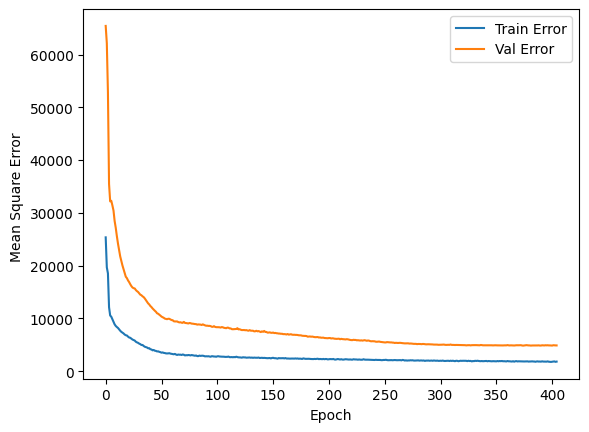

In [202]:
def plot_history():
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error ')
    plt.plot(hist['index'], hist['mse'], label='Train Error')
    plt.plot(hist['index'], hist['val_mse'], label = 'Val Error')
    plt.legend()
    # plt.ylim([0,50])

plot_history()

In [203]:
predictions = np.round(model.predict(X_test), 1)

52/52 [==============================] - 0s 2ms/step


In [204]:
mean_squared_error(y_test, predictions, squared=False)

54.26821392604169

In [205]:
r2_score(y_test, predictions)

0.9080289140959177

In [206]:
mini_holdout_encoded_df = mms.transform(mini_holdout_encoded_df)
predictions = model.predict(mini_holdout_encoded_df)
pd.DataFrame(predictions).to_csv('test-predictions.csv', index=False)
# len(mini_holdout_encoded_df)

2/2 [==============================] - 0s 5ms/step
